# QAOA for MaxCut

This notebook applies QAOA to a small Ising formulation of MaxCut and visualizes the resulting parameter landscape.


In [1]:
# Imports
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from problem.ising_problem import IsingProblem
from solver.quantum_solver.qaoa_solver.qaoa_mixers import add_ising_problem_ham, add_ising_mixer_ham


**Problem Definition**


In [2]:
n = 5
s0, s1, s2, s3, s4 = sp.symbols('s0 s1 s2 s3 s4')

# Star-graph toy instance written directly as an Ising cost Hamiltonian
cost_expr = s0*s4 + s1*s4 + s2*s4 + s3*s4
ising_problem = IsingProblem(expression=cost_expr)


In [3]:
def build_qaoa_circuit(ising_problem, n):
    """Builds the base QAOA circuit with unbound parameters."""
    qc = QuantumCircuit(n)
    
    #Uniform superposition
    for i in range(n):
        qc.h(i)
        
    #We apply problem and mixing hamiltonians (using your functions!)
    qc, gamma_params = add_ising_problem_ham(qc, ising_problem, n)
    qc, beta_params = add_ising_mixer_ham(qc, ising_problem, n)
    
    return qc, gamma_params[0], beta_params[0]


In [4]:
def run_single_QAOA(angles, qc, shots=1024):
    """Binds parameters and runs the circuit."""
    # Bind the angles to our parameters
    bound_qc = qc.assign_parameters(angles)
    
    # We must measure to get counts
    bound_qc.measure_all()
    
    sim = AerSimulator()
    result = sim.run(bound_qc, shots=shots).result()
    return result.get_counts()


In [5]:
def get_expectation_value(counts, shots=1024):
    """Computes the average cost from the measurement counts."""
    expected_value = 0
    
    for bitstring, count in counts.items():
        spins = [1 if b == '0' else -1 for b in reversed(bitstring)]
        
        # Calculate the cost: s1*s5 + s2*s5 + s3*s5 + s4*s5
        cost = (spins[0]*spins[4]) + (spins[1]*spins[4]) + (spins[2]*spins[4]) + (spins[3]*spins[4])
        expected_value += cost * count
        
    return expected_value / shots


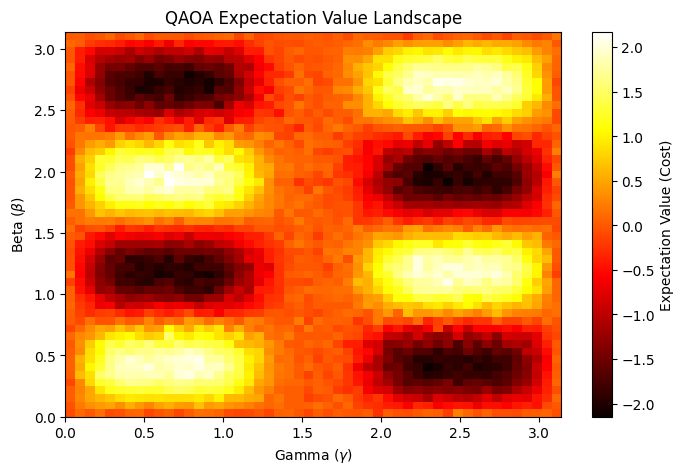

In [8]:
def plot_heatmap(ising_problem, n):
    """Evaluates the expectation value over a grid of gamma and beta values."""
    grid_size = 50
    gamma_vals = np.linspace(0, np.pi, grid_size)
    beta_vals = np.linspace(0, np.pi, grid_size)
    heatmap = np.zeros((grid_size, grid_size))
    
    # Build base circuit once
    qc, p_gamma, p_beta = build_qaoa_circuit(ising_problem, n)
    
    for i, b in enumerate(beta_vals):
        for j, g in enumerate(gamma_vals):
            # Pass the dictionary of parameters as requested
            angles = {p_gamma: g, p_beta: b}
            counts = run_single_QAOA(angles, qc.copy(), shots=512)
            heatmap[i, j] = get_expectation_value(counts, shots=512)
            
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.imshow(heatmap, origin='lower', extent=[0, np.pi, 0, np.pi], aspect='auto', cmap='hot')
    plt.colorbar(label='Expectation Value (Cost)')
    plt.xlabel(r'Gamma ($\gamma$)')
    plt.ylabel(r'Beta ($\beta$)')
    plt.title('QAOA Expectation Value Landscape')
    plt.show()

plot_heatmap(ising_problem, n)


This map shows how the "score" of our quantum answer changes as we adjust the $\gamma$ and $\beta$ settings. The dark areas are the "winning spots" where the computer finds the best solutions to our puzzle. Since the quantum gates work like rotations, you see the same patterns repeat across the whole grid.